## Initial Data Analysis — Protector Fleet Insurance

This notebook walks through every step of the initial data exploration:
- What each sheet contains (columns, types, nulls)
- Feature distributions
- How the sheets relate to each other
- Key findings that shaped our pipeline decisions

## 1. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_FILE = "data/raw/Case - Datasett -Analytics and AI Solutions Engineer.xlsx"

In [3]:
# load objects -header on row 0
objects = pd.read_excel(DATA_FILE, sheet_name="Objects")
print(f"Objects: {objects.shape[0]} rows × {objects.shape[1]} cols")
objects.head()

Objects: 2376 rows × 9 cols


,Client,regnr,Marke,Fordonsslag,Fordonsstatus,Karosserikod,Arsmodell,TotalVikt,Uwcategory
0,Client - 8,REGNR1,TOYOTA,PB,ITRAFIK,Fordon avsett för fler ändamål,2019.0,NaN,NaN
1,Client - 8,REGNR2,TOYOTA,PB,ITRAFIK,Halvkombi,2020.0,NaN,NaN
2,Client - 8,REGNR3,TOYOTA,PB,ITRAFIK,Halvkombi,2021.0,NaN,NaN
3,Client - 8,REGNR4,TOYOTA,PB,ITRAFIK,Halvkombi,2019.0,NaN,NaN
4,Client - 8,REGNR5,TOYOTA,PB,ITRAFIK,Fordon avsett för fler ändamål,2022.0,NaN,NaN


In [4]:
# load api data, first 2 rows blank → header=2
api_data = pd.read_excel(DATA_FILE, sheet_name='"External data - API data"', header=2)
print(f"API data: {api_data.shape[0]} rows  {api_data.shape[1]} cols")
api_data.head()

API data: 2067 rows  65 cols


,Client,regnr,Marke,Fordonsar,Arsmodell,Fordonsslag,Fordonsstatus,Karosserikod,DatumITrafik,TotalVikt,...,Karosskodny,Karossny,Karosskod2,Kaross2,Textkodfinns,Last_Synchronized,Fk_Chassinr,Egenklass,FSTATUS,FSTATUS_DATUM
0,Client - 10,REGNR2302,"VOLKSWAGEN, VW",2020,NaN,LB,ITRAFIK,Skåpbil,44074,3200.0,...,BB,Skåpbil,NaN,NaN,J,2023-01-09 14:34:40.822,701013,Lätt lastbil,NaN,NaN
1,Client - 10,REGNR2303,HYUNDAI GDH,2014,NaN,PB,ITRAFIK,Halvkombi,41873,1810.0,...,AB,Halvkombi,NaN,NaN,NaN,2023-01-09 14:34:23.543,10822,Personbil,NaN,NaN
2,Client - 10,REGNR2304,"VOLKSWAGEN, VW",2021,NaN,LB,ITRAFIK,Skåpbil,44393,2220.0,...,BB,Skåpbil,NaN,NaN,NaN,2023-01-09 14:34:32.019,1203486,Lätt lastbil,NaN,NaN
3,Client - 10,REGNR2305,MITSUBISHI KAOT,2014,NaN,LB,ITRAFIK,Lastbil,41786,2850.0,...,BA,Lastbil,NaN,NaN,NaN,2023-01-09 14:34:15.254,10824,Lätt lastbil,NaN,NaN
4,Client - 10,REGNR2306,RENAULT W,2014,NaN,LB,ITRAFIK,Skåpbil,41789,1950.0,...,BB,Skåpbil,NaN,NaN,NaN,2023-01-09 14:34:25.464,10825,Lätt lastbil,NaN,NaN


In [5]:
# load claims — first 2 rows blank → header=2
claims = pd.read_excel(DATA_FILE, sheet_name="Claims", header=2)
print(f"Claims: {claims.shape[0]} rows  {claims.shape[1]} cols")
claims.head()

Claims: 2049 rows  22 cols


,CLIENT,CLAIM_TYPE,CLAIM_CAUSE,CLAIM_YEAR,DAMAGE_DATE,LAST_MONTH_NET_PAID,LAST_MONTH_REMAINING_RESERVES,LAST_MONTH_INCURRED,DEDUCTIBLE,FLEET_TYPE,...,Reserves adj,Incurred adj,idx,Net paid idx,Reserves idx,Incurred idx,Incl. 0,Ex. 0,minor,major
0,Client - 10,Kasko,Annan olycka,2019,43511,0,0,0,0,Personbil,...,0,0,1.200558,0.000000,0.0,0.000000,1,0,0.000000,0.0
1,Client - 10,Bilansvar,Påkörd/bilolycka,2019,43721,0,0,0,0,NaN,...,0,0,1.177555,0.000000,0.0,0.000000,1,0,0.000000,0.0
2,Client - 10,"Ansvar, Vagn, Additional insurance","Påkjørt parkert bil, Annan olycka, Rental car",2020,44098,0,0,0,0,Lätt lastbil,...,0,0,1.154283,0.000000,0.0,0.000000,1,0,0.000000,0.0
3,Client - 10,"Ansvar, Additional insurance, Vagn","Påkjørt bakfra, Rental car, Annan olycka",2019,43721,0,0,0,0,Personbil,...,0,0,1.177555,0.000000,0.0,0.000000,1,0,0.000000,0.0
4,Client - 10,"Vagn, Kasko","Annan olycka, Kört/backat på fasta föremål",2019,43807,10168,0,10168,0,Lätt lastbil,...,0,10168,1.170561,11902.263928,0.0,11902.263928,1,1,11902.263928,0.0


In [6]:
# load UW categories — instruction text in rows 0-2, skip them
uw_cats = pd.read_excel(DATA_FILE, sheet_name="UW categories", header=None, skiprows=3)
uw_categories = uw_cats.iloc[:, 0].dropna().astype(str).tolist()
print(f"UW categories: {len(uw_categories)}")
uw_categories

UW categories: 16


['Brandfordon',
 'Buss',
 'Lätt brandfordon',
 'Lätt lastbil',
 'Lätt lastbil EL',
 'Moped',
 'Motorcykel/ATV',
 'Motorredskap lätt',
 'Motorredskap tungt',
 'Personbil',
 'Personbil EL',
 'Släp',
 'Terrängfordon',
 'Traktor, minitraktor, åkgräsklippare',
 'Tung lastbil',
 'Tungt släp']

In [7]:
# normalize Client columns — raw values are "Client - 8", extract number
objects["Client"] = objects["Client"].astype(str).str.extract(r'(\d+)')[0]
claims["CLIENT"] = claims["CLIENT"].astype(str).str.extract(r'(\d+)')[0]
print("Client values (Objects):", sorted(objects["Client"].unique(), key=int))
print("Client values (Claims):", sorted(claims["CLIENT"].unique(), key=int))

Client values (Objects): ['4', '6', '8', '10', '15', '17', '18', '19', '20', '21', '22', '23', '26', '29', '30', '34', '36', '39']
Client values (Claims): ['4', '6', '8', '10', '15', '17', '18', '19', '20', '21', '22', '23', '26', '29', '30', '34', '36', '39']


## Objects Sheet — Master Vehicle List

This is our **primary table**. Every row = one insured vehicle.
The `Uwcategory` column is empty — that's what we need to fill..

In [8]:
# columns and types
objects.dtypes

Client               str
regnr                str
Marke                str
Fordonsslag          str
Fordonsstatus        str
Karosserikod         str
Arsmodell        float64
TotalVikt        float64
Uwcategory       float64
dtype: object

In [9]:
# null counts per column
objects.isnull().sum()

Client              0
regnr               0
Marke               0
Fordonsslag       255
Fordonsstatus     255
Karosserikod       73
Arsmodell          36
TotalVikt        2334
Uwcategory       2376
dtype: int64

In [10]:
# Uwcategory — our output column, 100% empty
print(f"Uwcategory non-null: {objects['Uwcategory'].notna().sum()} / {objects.shape[0]}")
print("→ This is our OUTPUT — we classify every vehicle into one of 16 UW categories")

Uwcategory non-null: 0 / 2376
→ This is our OUTPUT — we classify every vehicle into one of 16 UW categories


<Axes: title={'center': 'Vehicles per Client'}, xlabel='Client'>

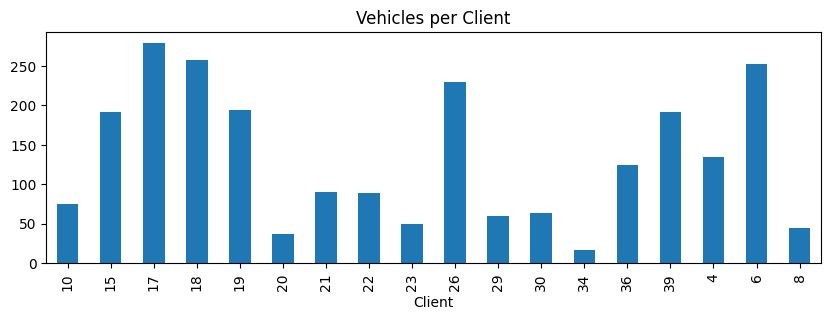

In [12]:
# vehicles per client
objects["Client"].value_counts().sort_index().plot.bar(title="Vehicles per Client", figsize=(10, 3))

In [13]:
# regnr — registration numbers
n_oreg = (objects["regnr"] == "OREG").sum()
print(f"Total vehicles: {objects.shape[0]}")
print(f"Unique regnr:   {objects['regnr'].nunique()}")
print(f"OREG (unregistered placeholder): {n_oreg}")
print(f" {n_oreg} vehicles have no real registration number")

Total vehicles: 2376
Unique regnr:   2144
OREG (unregistered placeholder): 233
 233 vehicles have no real registration number


In [14]:
# Marke — brand distribution (top 15)
print(f"Unique brands: {objects['Marke'].nunique()}")
objects["Marke"].value_counts().head(15)

Unique brands: 822


Marke
VOLKSWAGEN, VW         259
TOYOTA                 178
FORD                   148
RENAULT                135
NISSAN                  58
SEAT                    50
SKODA                   47
PEUGEOT                 46
BRENDERUP               42
VOLKSWAGEN, VW  2KN     41
KIA                     27
VOLVO                   27
RENAULT Z               25
SUBARU                  23
RENAULT W               19
Name: count, dtype: int64

In [15]:
# Fordonsslag — vehicle type code
print("Vehicle type codes:")
print("  PB = Personbil (car)")
print("  LB = Lastbil (truck)")
print("  SL = Släp (trailer)")
print("  MC = Motorcykel")
print("  BU = Buss")
print("  TR = Traktor")
print("  NaN = mostly OREG vehicles\n")
objects["Fordonsslag"].value_counts(dropna=False)

Vehicle type codes:
  PB = Personbil (car)
  LB = Lastbil (truck)
  SL = Släp (trailer)
  MC = Motorcykel
  BU = Buss
  TR = Traktor
  NaN = mostly OREG vehicles



Fordonsslag
PB        917
LB        692
SLÄP      348
NaN       255
TR         75
MRED       24
TGSK       19
BUSS       12
MOPED      10
TGHJUL     10
TGV         8
TGSNÖ       5
MC          1
Name: count, dtype: int64

In [16]:
# confirm: null Fordonsslag = OREG vehicles
n_null_fs = objects["Fordonsslag"].isna().sum()
oreg_null_fs = objects[(objects["regnr"] == "OREG") & (objects["Fordonsslag"].isna())].shape[0]
print(f"Null Fordonsslag: {n_null_fs}")
print(f"Of which OREG:    {oreg_null_fs}")
print(f"Almost all null Fordonsslag are OREG — no vehicle type code for unregistered items")

Null Fordonsslag: 255
Of which OREG:    233
Almost all null Fordonsslag are OREG — no vehicle type code for unregistered items


In [17]:
# Fordonsstatus — vehicle status
objects["Fordonsstatus"].value_counts(dropna=False)

Fordonsstatus
ITRAFIK    2067
NaN         255
AVST         54
Name: count, dtype: int64

In [18]:
# Karosserikod — body type code (top 15)
print(f"Unique body types: {objects['Karosserikod'].nunique()}")
objects["Karosserikod"].value_counts().head(15)

Unique body types: 127


Karosserikod
Stationsvagn kombivagn            418
Skåpbil                           343
Halvkombi                         250
Fordon avsett för fler ändamål    230
Lastbil                           192
Flak - Godslåda                   151
Släpkärra                         124
Brandfordon                       102
Traktor                            69
Skåp                               32
Hjullastare                        28
Motorredskap (oreg)                24
Gräsklippare                       19
Åkgräsklippare                     18
Pick-up                            17
Name: count, dtype: int64

Range:  1900 2023
Median: 2017
Null:   36


Text(0.5, 1.0, 'Model Year Distribution')

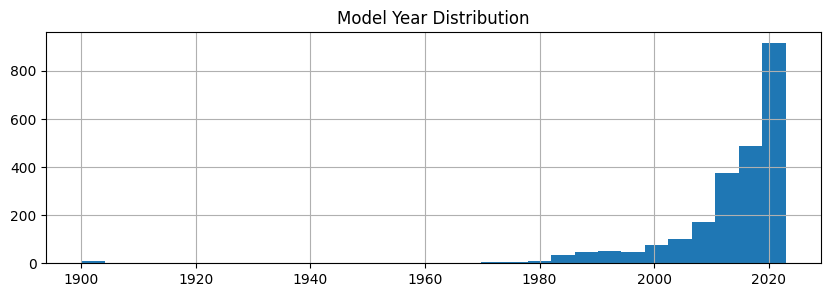

In [20]:
# Arsmodell — model year
ars = objects["Arsmodell"].dropna()
print(f"Range:  {int(ars.min())} {int(ars.max())}")
print(f"Median: {int(ars.median())}")
print(f"Null:   {objects['Arsmodell'].isna().sum()}")
import matplotlib.pyplot as plt

ars.hist(bins=30, figsize=(10, 3))
plt.title("Model Year Distribution")

In [21]:
# TotalVikt — total weight in Objects sheet
n_wt = objects["TotalVikt"].notna().sum()
print(f"Non-null: {n_wt} / {objects.shape[0]} ({n_wt/objects.shape[0]*100:.0f}%)")
print("Almost entirely missing in Objects! But well-populated in API data (see below)")

Non-null: 42 / 2376 (2%)
Almost entirely missing in Objects! But well-populated in API data (see below)


## API Data Sheet — External Vehicle Registry

This comes from an external vehicle registry API. 65 columns, but most are internal IDs / timestamps.
We only keep ~10 useful columns. **Egenklass is THE key column for classification.**

In [22]:
# all 65 columns
print(f"Shape: {api_data.shape}")
list(api_data.columns)

Shape: (2067, 65)


['Client',
 'regnr',
 'Marke',
 'Fordonsar',
 'Arsmodell',
 'Fordonsslag',
 'Fordonsstatus',
 'Karosserikod',
 'DatumITrafik',
 'TotalVikt',
 'Motoreffekt',
 'Yrkesanvandning',
 'Stationsnr',
 'Station',
 'Vagmatarstalln',
 'Besbefriad',
 'Regtyp',
 'Tillvman',
 'Antaxlar',
 'Dackdimfram',
 'Dackdimbak',
 'Kopplkod1',
 'Effektenhet',
 'Cylindervol',
 'Drivmedelskod',
 'Drivmedel',
 'Altdrivmedel',
 'Vaxellada',
 'Totalvikturspr',
 'Lyftkap',
 'Utrid1',
 'Utrtext1',
 'Utrid2',
 'Utrtext2',
 'Utrid3',
 'Utrtext3',
 'Typmobilkr',
 'Maxslapvikt',
 'Maxslapviktb',
 'Langdver2',
 'Breddver2',
 'Hojd',
 'Bussklass',
 'Fordonkateu',
 'Fordonslagsklass',
 'Antpassver2',
 'Antstaendepass',
 'Antsittpass',
 'Krockkuddeframre',
 'Karossver2',
 'Handelsbet',
 'Miljobiltillhor',
 'Dackdimaxel1',
 'Dackdimaxel2',
 'Trafiksakerhetsteknik',
 'Karosskodny',
 'Karossny',
 'Karosskod2',
 'Kaross2',
 'Textkodfinns',
 'Last_Synchronized',
 'Fk_Chassinr',
 'Egenklass',
 'FSTATUS',
 'FSTATUS_DATUM']

In [23]:
# useful columns in API data — many internal IDs, timestamps, codes that we won't use for modeling
useful = ["Client", "regnr", "Marke", "Fordonsslag", "Karosserikod",
          "Egenklass", "TotalVikt", "Motoreffekt", "Handelsbet", "Karossny", "Drivmedel"]
useful_present = [c for c in useful if c in api_data.columns]
print(f"Useful columns: {len(useful_present)} / {api_data.shape[1]}")
print(f"Dropped: {api_data.shape[1] - len(useful_present)} columns (internal IDs, timestamps, codes)")

Useful columns: 11 / 65
Dropped: 54 columns (internal IDs, timestamps, codes)


In [24]:
# nulls in columns
for c in useful_present:
    n = api_data[c].isna().sum()
    pct = n / api_data.shape[0] * 100
    print(f"  {c:20s}: {n:5d} nulls ({pct:.1f}%)")

  Client              :     0 nulls (0.0%)
  regnr               :     0 nulls (0.0%)
  Marke               :     0 nulls (0.0%)
  Fordonsslag         :     0 nulls (0.0%)
  Karosserikod        :    34 nulls (1.6%)
  Egenklass           :     0 nulls (0.0%)
  TotalVikt           :    22 nulls (1.1%)
  Motoreffekt         :   424 nulls (20.5%)
  Handelsbet          :   510 nulls (24.7%)
  Karossny            :    34 nulls (1.6%)
  Drivmedel           :   357 nulls (17.3%)


In [25]:
# Egenklass: THE key classification column
print("Egenklass = vehicle's own class from the registry")
print("This is what we map to UW categories\n")
api_data["Egenklass"].value_counts(dropna=False)

Egenklass = vehicle's own class from the registry
This is what we map to UW categories



Egenklass
Personbil         857
Lätt lastbil      455
Lätt släp         171
Släp              141
???               118
Brandbil          116
Brandbil lätt     100
Lastbil            45
Traktor            25
Tungt släp         19
Buss               12
Moped               4
Alla släp           3
Motorcykel/ATV      1
Name: count, dtype: int64

In [26]:
# how many "???" (unknown class)?
n_qqq = (api_data["Egenklass"] == "???").sum()
print(f"'???' entries: {n_qqq}")
print("→ These vehicles have unknown class — need alternative classification")

'???' entries: 118
→ These vehicles have unknown class — need alternative classification


In [27]:
# Drivmedel — fuel type (needed for EL/electric detection)
if "Drivmedel" in api_data.columns:
    print("Fuel types:")
    print(api_data["Drivmedel"].value_counts(dropna=False).head(10))
    n_el = api_data["Drivmedel"].astype(str).str.contains("El", case=False, na=False).sum()
    print(f"\nElectric vehicles: {n_el}")
    print("→ These could be mapped to 'Personbil EL' or 'Lätt lastbil EL' categories")

Fuel types:
Drivmedel
DIESEL      1096
BENSIN       420
NaN          357
EL           122
CNG           41
METANGAS      31
Name: count, dtype: int64

Electric vehicles: 1218
→ These could be mapped to 'Personbil EL' or 'Lätt lastbil EL' categories


Non-null: 2045 / 2067
Range: 243 42000 kg
Median: 2100 kg


Text(0.5, 1.0, 'Vehicle Weight Distribution (API data)')

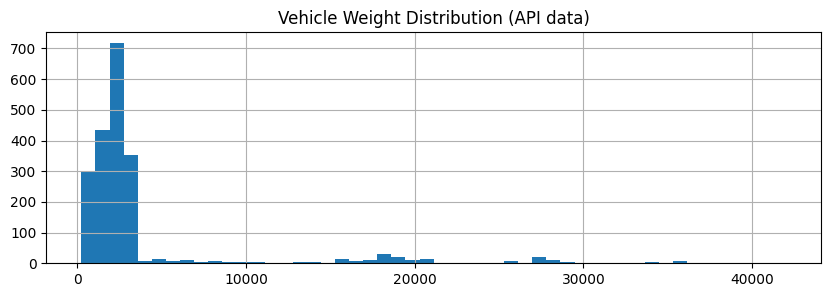

In [28]:
# TotalVikt in API — much better than Objects
print(f"Non-null: {api_data['TotalVikt'].notna().sum()} / {api_data.shape[0]}")
print(f"Range: {api_data['TotalVikt'].min():.0f} {api_data['TotalVikt'].max():.0f} kg")
print(f"Median: {api_data['TotalVikt'].median():.0f} kg")
api_data["TotalVikt"].dropna().hist(bins=50, figsize=(10, 3))
plt.title("Vehicle Weight Distribution (API data)")

Non-null: 1643 | Range: 18 5150 kW


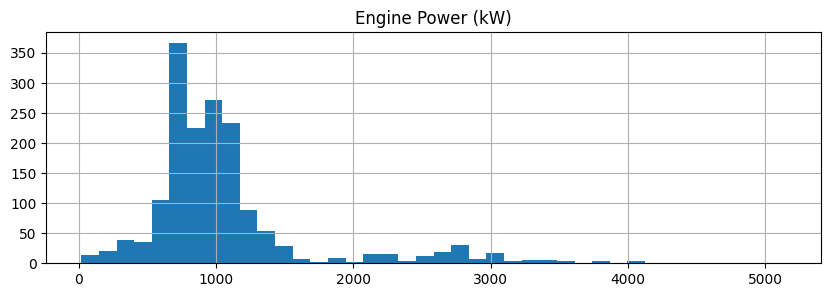

In [29]:
# Motoreffekt — engine power
if "Motoreffekt" in api_data.columns:
    me = api_data["Motoreffekt"].dropna()
    print(f"Non-null: {len(me)} | Range: {me.min():.0f} {me.max():.0f} kW")
    me.hist(bins=40, figsize=(10, 3))
    plt.title("Engine Power (kW)")

## Claims Sheet — Claims History

Each row = one insurance claim. Contains financial columns for loss amounts,
claim types, and yearly aggregation flags.

In [30]:
# columns and types
claims.dtypes

CLIENT                               str
CLAIM_TYPE                           str
CLAIM_CAUSE                          str
CLAIM_YEAR                         int64
DAMAGE_DATE                        int64
LAST_MONTH_NET_PAID                int64
LAST_MONTH_REMAINING_RESERVES      int64
LAST_MONTH_INCURRED                int64
DEDUCTIBLE                         int64
FLEET_TYPE                           str
FLEET_GROUP                          str
Net paid adj                       int64
Reserves adj                       int64
Incurred adj                       int64
idx                              float64
Net paid idx                     float64
Reserves idx                     float64
Incurred idx                     float64
Incl. 0                            int64
Ex. 0                              int64
minor                            float64
major                            float64
dtype: object

In [31]:
# ⚠ column name mismatch
print("Objects uses: 'Client'")
print("Claims uses:  'CLIENT' (uppercase)")
print("We rename CLIENT → Client in our pipeline for consistent joins")

Objects uses: 'Client'
Claims uses:  'CLIENT' (uppercase)
We rename CLIENT → Client in our pipeline for consistent joins


In [32]:
# unique clients with claims
print(f"Clients with claims: {claims['CLIENT'].nunique()}")
print(f"Total claims: {claims.shape[0]}")

Clients with claims: 18
Total claims: 2049


In [33]:
# DAMAGE_DATE — stored as Excel serial number, not a real date!
print(f"Raw dtype: {claims['DAMAGE_DATE'].dtype}")
print(f"Sample raw values: {claims['DAMAGE_DATE'].head(3).tolist()}")

# convert: Excel serial → datetime
damage_dates = pd.to_datetime(claims["DAMAGE_DATE"], unit="D", origin="1899-12-30", errors="coerce")
print(f"\nAfter conversion: {damage_dates.min().date()} to {damage_dates.max().date()}")
print("Origin '1899-12-30' is the Excel epoch for serial date numbers")

Raw dtype: int64
Sample raw values: [43511, 43721, 44098]

After conversion: 2019-01-02 to 2023-08-18
Origin '1899-12-30' is the Excel epoch for serial date numbers


<Axes: title={'center': 'Claims per Year'}, xlabel='CLAIM_YEAR'>

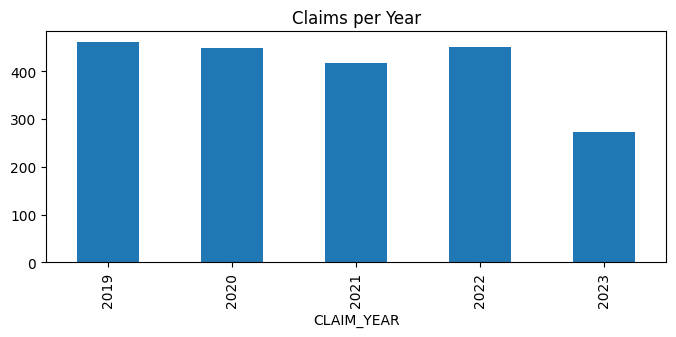

In [34]:
# CLAIM_YEAR distribution
claims["CLAIM_YEAR"].value_counts().sort_index().plot.bar(title="Claims per Year", figsize=(8, 3))

In [35]:
# financial columns summary
for col in ["LAST_MONTH_NET_PAID", "LAST_MONTH_INCURRED", "DEDUCTIBLE",
            "Net paid idx", "Incurred idx"]:
    if col in claims.columns:
        s = pd.to_numeric(claims[col], errors="coerce")
        print(f"  {col:30s}: mean={s.mean():>10,.0f}  median={s.median():>10,.0f}  max={s.max():>12,.0f}")

  LAST_MONTH_NET_PAID           : mean=     7,469  median=       198  max=     541,779
  LAST_MONTH_INCURRED           : mean=     8,489  median=       600  max=     541,779
  DEDUCTIBLE                    : mean=        35  median=         0  max=      23,332
  Net paid idx                  : mean=     8,235  median=       228  max=     573,741
  Incurred idx                  : mean=     9,269  median=       699  max=     573,741


In [36]:
# zero-cost claims
inc = pd.to_numeric(claims["Incurred idx"], errors="coerce").fillna(0)
n_zero = (inc == 0).sum()
print(f"Zero-cost claims: {n_zero} / {claims.shape[0]} ({n_zero/claims.shape[0]*100:.0f}%)")
print("→ 44% of claims have zero incurred cost (glass damage, minor events)")

Zero-cost claims: 899 / 2049 (44%)
→ 44% of claims have zero incurred cost (glass damage, minor events)


In [37]:
# claim size flags
for col in ["Incl. 0", "Ex. 0", "minor", "major"]:
    if col in claims.columns:
        print(f"{col}: {claims[col].value_counts().to_dict()}")

Incl. 0: {1: 2049}
Ex. 0: {1: 1147, 0: 902}
minor: {0.0: 925, 10858.573439082806: 10, 10895.028648043599: 9, 13962.831335353108: 8, 10932.483798200585: 8, 14114.117473707563: 6, 11010.42864385605: 6, 657.9748849067863: 5, 13914.994086843451: 5, 662.1257099551573: 4, 559.5246931646334: 4, 13868.433950701436: 4, 1159.1170934207717: 4, 538.343087651007: 4, 16346.066265077332: 3, 641.95282797615: 3, 11092.480098307478: 3, 11050.936368222307: 3, 3051.9528718070915: 3, 10970.9475035265: 3, 642.8027432622689: 3, 500.61870484878284: 2, 68.86403063744154: 2, 660.3071311426304: 2, 1170.5609685452082: 2, 21605.791697146335: 2, 16291.371662554431: 2, 466.8747839826546: 2, 14011.956697888461: 2, 16459.969099349837: 2, 480.00621922571844: 2, 641.1832334166094: 2, 27.467575846263824: 2, 522.4995855994177: 2, 540.2512891166976: 2, 634.8558317856307: 2, 11902.263928167678: 1, 4320.128498177386: 1, 29186.660785124055: 1, 3460.9991709527444: 1, 14166.625192362852: 1, 6603.65978079836: 1, 4985.64682635969

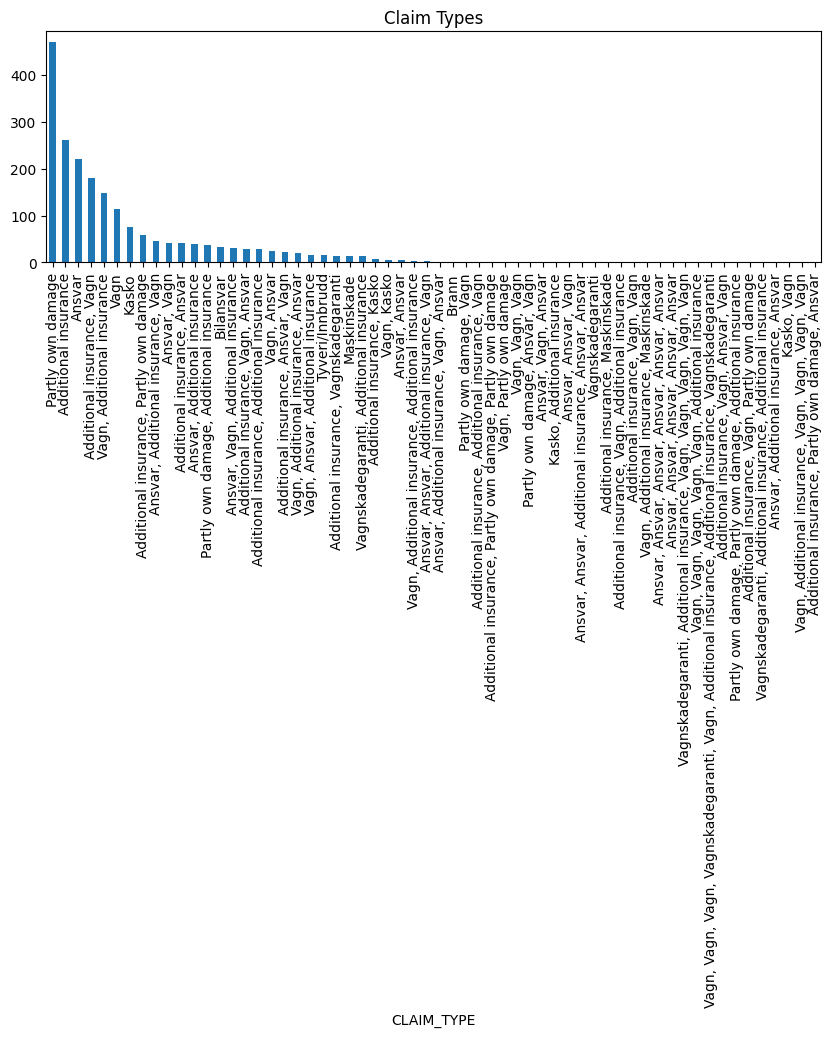

In [38]:
# CLAIM_TYPE distribution
if "CLAIM_TYPE" in claims.columns:
    claims["CLAIM_TYPE"].value_counts().plot.bar(title="Claim Types", figsize=(10, 3))

## UW Categories — The 16 Target Labels

These are the valid underwriting categories. Every vehicle must be assigned exactly one.

In [39]:
# the 16 categories
for i, cat in enumerate(uw_categories, 1):
    print(f"  {i:2d}. {cat}")

   1. Brandfordon
   2. Buss
   3. Lätt brandfordon
   4. Lätt lastbil
   5. Lätt lastbil EL
   6. Moped
   7. Motorcykel/ATV
   8. Motorredskap lätt
   9. Motorredskap tungt
  10. Personbil
  11. Personbil EL
  12. Släp
  13. Terrängfordon
  14. Traktor, minitraktor, åkgräsklippare
  15. Tung lastbil
  16. Tungt släp


In [40]:
# Egenklass vs UW — not a 1:1 mapping!
egenklass_vals = api_data["Egenklass"].dropna()
egenklass_vals = egenklass_vals[egenklass_vals != "???"].unique()

print(f"Egenklass unique values: {len(egenklass_vals)}")
print(f"UW categories:           {len(uw_categories)}")

# which UW categories have no direct Egenklass source?
no_source = set(uw_categories) - set(egenklass_vals)
print(f"\nUW categories NOT in Egenklass: {sorted(no_source)}")
print("→ These categories need rule-based mapping or special detection (e.g. EL = electric)")

Egenklass unique values: 13
UW categories:           16

UW categories NOT in Egenklass: ['Brandfordon', 'Lätt brandfordon', 'Lätt lastbil EL', 'Motorredskap lätt', 'Motorredskap tungt', 'Personbil EL', 'Terrängfordon', 'Traktor, minitraktor, åkgräsklippare', 'Tung lastbil']
→ These categories need rule-based mapping or special detection (e.g. EL = electric)


In [41]:
# our Egenklass → UW mapping table
mapping = {
    "Personbil": "Personbil",
    "Lätt lastbil": "Lätt lastbil",
    "Lätt släp": "Släp",           # renamed
    "Släp": "Släp",
    "Brandbil": "Brandfordon",     # renamed
    "Brandbil lätt": "Lätt brandfordon",  # renamed
    "Lastbil": "Tung lastbil",    # renamed (weight evidence: all >3500kg)
    "Traktor": "Traktor, minitraktor, åkgräsklippare",
    "Tungt släp": "Tungt släp",
    "Buss": "Buss",
    "Moped": "Moped",
    "Alla släp": "Släp",
    "Motorcykel/ATV": "Motorcykel/ATV",
}
print("Egenklass → UW Kategori mapping:")
for k, v in mapping.items():
    changed = " ← renamed" if k != v else ""
    print(f"  {k:25s} → {v}{changed}")

Egenklass → UW Kategori mapping:
  Personbil                 → Personbil
  Lätt lastbil              → Lätt lastbil
  Lätt släp                 → Släp ← renamed
  Släp                      → Släp
  Brandbil                  → Brandfordon ← renamed
  Brandbil lätt             → Lätt brandfordon ← renamed
  Lastbil                   → Tung lastbil ← renamed
  Traktor                   → Traktor, minitraktor, åkgräsklippare ← renamed
  Tungt släp                → Tungt släp
  Buss                      → Buss
  Moped                     → Moped
  Alla släp                 → Släp ← renamed
  Motorcykel/ATV            → Motorcykel/ATV


## Data Relationships: How Sheets Connect

```
Objects (2,376 vehicles)
    │
    ├── LEFT JOIN on regnr ──→ API Data (2,067 records)
    │     → 2,067 matched, 77 missing, 232 OREG
    │     → brings Egenklass for classification
    │
    └── JOIN on Client ──→ Claims (2,049 claims)
          → all 18 clients match
          → ⚠ no regnr in Claims = client-level only
```

In [42]:
# Objects ↔ API data (join on regnr)
obj_reg = set(objects["regnr"].dropna().unique())
api_reg = set(api_data["regnr"].dropna().unique())

print("Objects ↔ API Data (join key: regnr)")
print(f"  Objects vehicles:  {len(obj_reg)}")
print(f"  API data vehicles: {len(api_reg)}")
print(f"  Matched (both):    {len(obj_reg & api_reg)}")
print(f"  Only in Objects:   {len(obj_reg - api_reg)} ← mostly OREG")
print(f"  Only in API:       {len(api_reg - obj_reg)}")

Objects ↔ API Data (join key: regnr)
  Objects vehicles:  2144
  API data vehicles: 2067
  Matched (both):    2067
  Only in Objects:   77 ← mostly OREG
  Only in API:       0


In [43]:
# confirm: "only in Objects" are OREG
only_obj_df = objects[objects["regnr"].isin(obj_reg - api_reg)]
oreg_count = (only_obj_df["regnr"] == "OREG").sum()
print(f"Of {len(obj_reg - api_reg)} unmatched, {oreg_count} are OREG")
print("→ OREG vehicles don't exist in the registry API — they're unregistered equipment")

Of 77 unmatched, 233 are OREG
→ OREG vehicles don't exist in the registry API — they're unregistered equipment


In [44]:
# Objects ↔ Claims (join key: Client)
obj_clients = set(objects["Client"].dropna().unique())
cl_clients = set(claims["CLIENT"].dropna().unique())

print(f"Object clients:  {len(obj_clients)}")
print(f"Claims clients:  {len(cl_clients)}")
print(f"Matched:         {len(obj_clients & cl_clients)}")
print(f"\nClaims has NO regnr column")
print("We can only calculate risk at CLIENT level, not per vehicle")

Object clients:  18
Claims clients:  18
Matched:         18

Claims has NO regnr column
We can only calculate risk at CLIENT level, not per vehicle


##  OREG Vehicles 

232 vehicles have `regnr="OREG"` — a placeholder for unregistered equipment.
These include lawn mowers, generators, excavators, ATVs, and snow blowers.
They have **no Fordonsslag**, **no API match**, and **no Egenklass**.

In [45]:
# OREG overview
oreg = objects[objects["regnr"] == "OREG"].copy()
print(f"Total OREG vehicles: {oreg.shape[0]}")
print(f"Null Fordonsslag:    {oreg['Fordonsslag'].isna().sum()}")
print(f"Null Fordonsstatus:  {oreg['Fordonsstatus'].isna().sum()}")

Total OREG vehicles: 233
Null Fordonsslag:    233
Null Fordonsstatus:  233


<Axes: title={'center': 'OREG Vehicles per Client'}, xlabel='Client'>

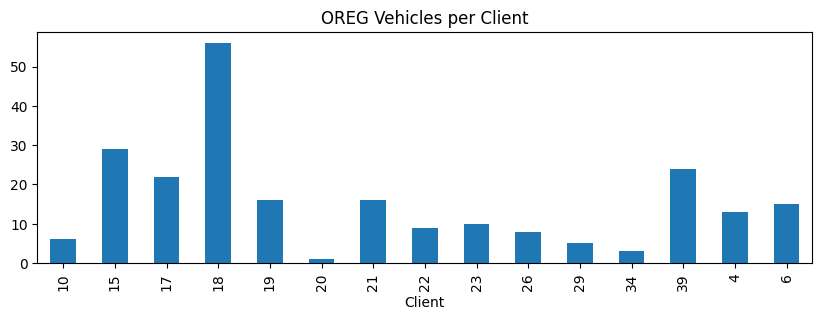

In [46]:
# OREG per client
oreg["Client"].value_counts().sort_index().plot.bar(
    title="OREG Vehicles per Client", figsize=(10, 3))

In [47]:
# OREG brands — what are these things?
print("Top OREG brands:")
print(oreg["Marke"].value_counts().head(15))
print()
print("Husqvarna = lawn mowers, chainsaws")
print("Honda = generators, small engines")
print("Yamaha = ATVs, snowmobiles")
print("Caterpillar = excavators")
print("These are non-road equipment, need LLM or heuristic to classify")

Top OREG brands:
Marke
Husqvarna                                             5
Yunque                                                4
Crescent                                              4
Flexitrac 1238 CAB-2S                                 4
Huskvarna Rider 316 TXS AWD                           4
GODIVA                                                4
Toro 3500D Groundmaster Gräsklippare, modell 30839    3
Waterous E400                                         3
Huskvarna Rider 316TS AWD                             3
WR27                                                  3
VOLVO/WATEROUS                                        3
GODIVA MSP                                            2
Norrlandsvagnar                                       2
Toro 4010D                                            2
JOHN DEERE Z997                                       2
Name: count, dtype: int64

Husqvarna = lawn mowers, chainsaws
Honda = generators, small engines
Yamaha = ATVs, snowmobiles
Caterpillar = 

In [48]:
# OREG body types
print("OREG body types (Karosserikod):")
oreg["Karosserikod"].value_counts(dropna=False).head(10)

OREG body types (Karosserikod):


Karosserikod
NaN                      33
Motorredskap (oreg)      24
Åkgräsklippare           18
Gräsklippare             18
Hjullastare               8
Snöslunga                 7
Redskapsbärare            6
Traktor                   6
Bogserbar motorspruta     5
Moped                     5
Name: count, dtype: int64

## Client 18 Our Deep-Dive Target

In [49]:
# filter Client 18
c18_obj = objects[objects["Client"] == "18"].copy()
c18_claims = claims[claims["CLIENT"] == "18"].copy()
print(f"Vehicles: {c18_obj.shape[0]}")
print(f"Claims:   {c18_claims.shape[0]}")

Vehicles: 258
Claims:   191


In [50]:
# fleet composition
print("Fordonsslag (vehicle types):")
print(c18_obj["Fordonsslag"].value_counts(dropna=False))
n_oreg = (c18_obj["regnr"] == "OREG").sum()
print(f"\nOREG vehicles: {n_oreg} / {c18_obj.shape[0]} ({n_oreg/c18_obj.shape[0]*100:.0f}%)")
print("Client 18 has the MOST OREG vehicles of any client")

Fordonsslag (vehicle types):
Fordonsslag
PB      104
LB       56
NaN      56
SLÄP     34
TR        6
MRED      1
TGV       1
Name: count, dtype: int64

OREG vehicles: 56 / 258 (22%)
Client 18 has the MOST OREG vehicles of any client


Model years: 1983 2023 | Median: 2018


Text(0.5, 1.0, 'Client 18 — Model Year Distribution')

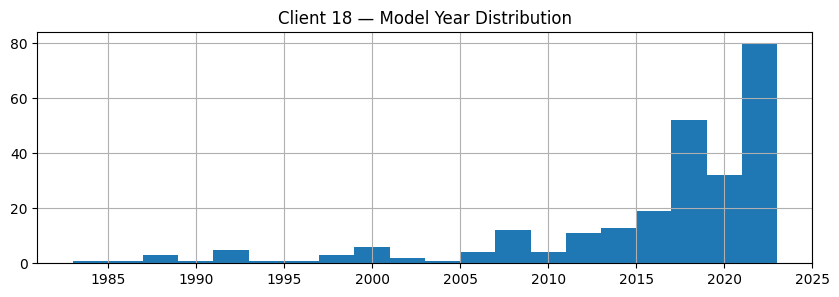

In [51]:
# model year spread
ars18 = c18_obj["Arsmodell"].dropna()
print(f"Model years: {int(ars18.min())} {int(ars18.max())} | Median: {int(ars18.median())}")
ars18.hist(bins=20, figsize=(10, 3))
plt.title("Client 18 — Model Year Distribution")

<Axes: title={'center': 'Client 18 :Claims per Year'}, xlabel='CLAIM_YEAR'>

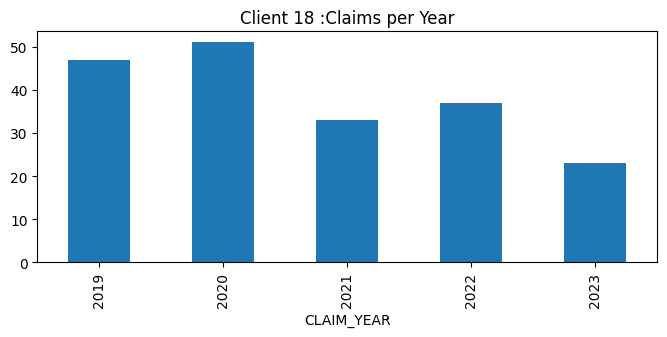

In [52]:
# claims per year
c18_claims["CLAIM_YEAR"].value_counts().sort_index().plot.bar(
    title="Client 18 :Claims per Year", figsize=(8, 3))

In [53]:
# claim frequency
n_years = c18_claims["CLAIM_YEAR"].nunique()
n_vehicles = c18_obj.shape[0]
freq = c18_claims.shape[0] / (n_vehicles * n_years)
print(f"Claim frequency: {c18_claims.shape[0]} / ({n_vehicles}  {n_years}) = {freq:.3f}")
print(" 0.148 claims per vehicle per year")

Claim frequency: 191 / (258  5) = 0.148
 0.148 claims per vehicle per year


In [54]:
# claim costs
inc18 = pd.to_numeric(c18_claims["Incurred idx"], errors="coerce").fillna(0)
nonzero = inc18[inc18 > 0]

print(f"Total incurred:    {inc18.sum():>12,.0f} SEK")
print(f"Mean (all):        {inc18.mean():>12,.0f} SEK")
print(f"Mean (non-zero):   {nonzero.mean():>12,.0f} SEK")
print(f"Median (non-zero): {nonzero.median():>12,.0f} SEK")
print(f"Max:               {inc18.max():>12,.0f} SEK")
print(f"\nZero-cost: {len(inc18) - len(nonzero)} / {len(inc18)} ({(len(inc18)-len(nonzero))/len(inc18)*100:.0f}%)")

Total incurred:       1,557,285 SEK
Mean (all):               8,153 SEK
Mean (non-zero):         12,870 SEK
Median (non-zero):        6,493 SEK
Max:                    159,221 SEK

Zero-cost: 70 / 191 (37%)


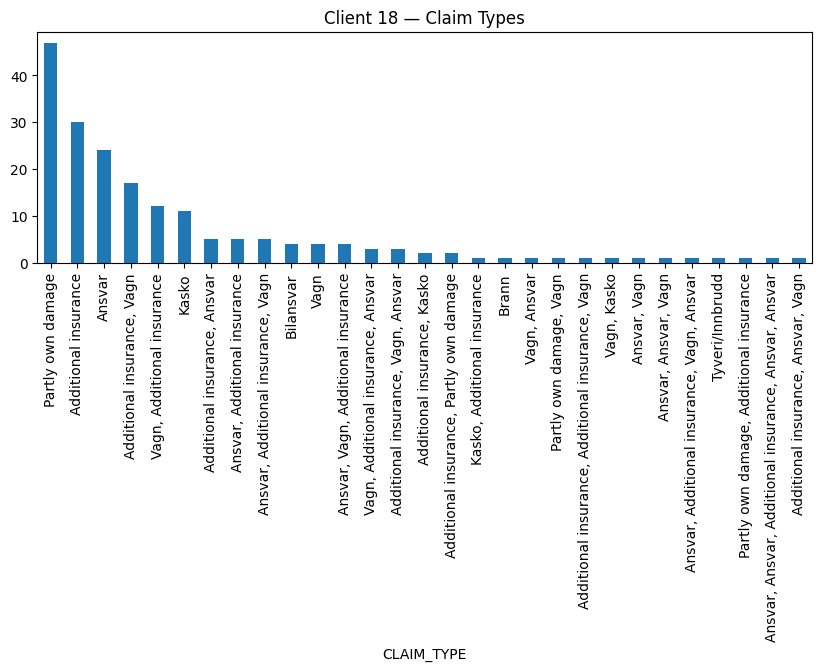

In [55]:
# claim types
if "CLAIM_TYPE" in c18_claims.columns:
    c18_claims["CLAIM_TYPE"].value_counts().plot.bar(
        title="Client 18 — Claim Types", figsize=(10, 3))

In [56]:
# top brands in Client 18
c18_obj["Marke"].value_counts().head(10)

Marke
VOLKSWAGEN, VW            65
FORD                      26
SEAT                      23
RENAULT                   14
FIAT                       8
BRENDERUP                  7
VOLKSWAGEN, VW  2KN        6
OPEL                       4
GISEBO 750/TRANSPORTER     4
NISSAN                     4
Name: count, dtype: int64

## Portfolio Comparison How Client 18 Compares

In [57]:
# claim frequency by client
rows = []
for client in sorted(objects["Client"].dropna().unique(), key=int):
    n_veh = objects[objects["Client"] == client].shape[0]
    cl_c = claims[claims["CLIENT"] == client]
    n_cl = cl_c.shape[0]
    n_yr = max(cl_c["CLAIM_YEAR"].nunique(), 1)
    f = n_cl / (n_veh * n_yr) if n_veh > 0 else 0
    rows.append({"Client": client, "Vehicles": n_veh, "Claims": n_cl,
                 "Years": n_yr, "Frequency": round(f, 3)})

comparison = pd.DataFrame(rows)
comparison.style.applymap(
    lambda v: "background-color: #90EE90" if v == "18" else "",
    subset=["Client"]
)

AttributeError: 'Styler' object has no attribute 'applymap'

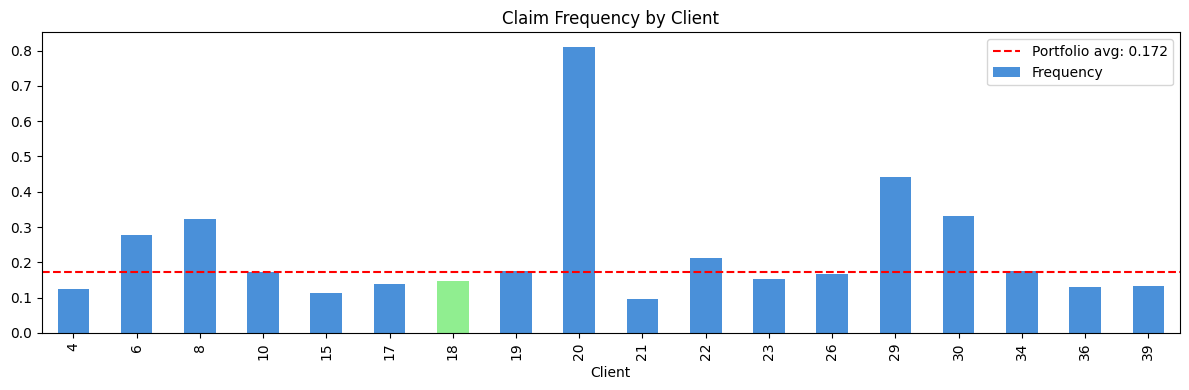

In [58]:
# bar chart — frequency comparison
comparison.set_index("Client")["Frequency"].plot.bar(
    title="Claim Frequency by Client", figsize=(12, 4), color=[
        "#90EE90" if c == "18" else "#4A90D9" for c in comparison["Client"]
    ])

# portfolio average line
port_freq = claims.shape[0] / (objects.shape[0] * claims["CLAIM_YEAR"].nunique())
import matplotlib.pyplot as plt
plt.axhline(y=port_freq, color="red", linestyle="--", label=f"Portfolio avg: {port_freq:.3f}")
plt.legend()
plt.tight_layout()

## Key Findings Summary

### Data Quality
- `Uwcategory` is 100% empty → this is our **output** to fill
- `TotalVikt` nearly all null in Objects but well-populated in API data
- 118 vehicles have `Egenklass="???"` → can't classify with simple mapping
- `DAMAGE_DATE` stored as Excel serial numbers → needs conversion with origin `1899-12-30`
- `CLIENT` vs `Client` naming inconsistency between sheets

### The OREG Problem
- 232 vehicles with `regnr="OREG"` (not in vehicle registry)
- Include lawn mowers, generators, ATVs, excavators, snow blowers
- No API match → no Egenklass → need LLM or heuristic classification
- Client 18 has the most OREG vehicles (56)

### Classification Strategy (3-tier)
1. **Rule-based** — Egenklass → UW mapping (covers ~82%)
2. **LLM** — Google Gemini for OREG + "???" vehicles
3. **Heuristic** — Fordonsslag code fallback (safety net)

### Client 18 Profile
- 258 vehicles, 191 claims, 5 years
- **Below-average** claim frequency (0.148 vs portfolio 0.229) → good risk
- **Below-average** claim severity → good risk
- Most OREG vehicles of any client (56)

### Claims Limitation
- Claims have **no regnr** → risk is per-client, not per-vehicle
- This is a real-world data limitation we acknowledge in our pricing model